In [1]:
import pickle

import matplotlib.pyplot as plt
import healpy as hp
import numpy as np

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

In [3]:
data2 = pickle.load(open("/media/mattia/Hard Disk/data/test_differences/maps/jan+feb.pkl", "rb"))

In [4]:
data_jan = pickle.load(open("/media/mattia/Hard Disk/data/test_differences/maps/january.pkl", "rb"))
data_feb = pickle.load(open("/media/mattia/Hard Disk/data/test_differences/maps/february.pkl", "rb"))

In [6]:
nus = data_jan["nus"]
Nrec = nus.shape[0] - 7

maps_input_jan = data_jan["maps_in_convolved"]
maps_rec_jan = data_jan["maps"][:Nrec]
maps_res_jan = maps_input_jan - maps_rec_jan
center_jan = data_jan["center"]
seenpix_jan = data_jan["seenpix"]

maps_input_feb = data_feb["maps_in_convolved"]
maps_rec_feb = data_feb["maps"][:Nrec]
maps_res_feb = maps_input_feb - maps_rec_feb
center_feb = data_feb["center"]
seenpix_feb = data_feb["seenpix"]


In [7]:
nus = data2["nus"]
Nrec = nus.shape[0] - 7

maps_input_2 = data2["maps_in_convolved"]
maps_rec_2 = data2["maps"][:Nrec]
maps_res_2 = maps_input_2 - maps_rec_2
center_2 = data2["center"]
seenpix_2 = data2["seenpix"]

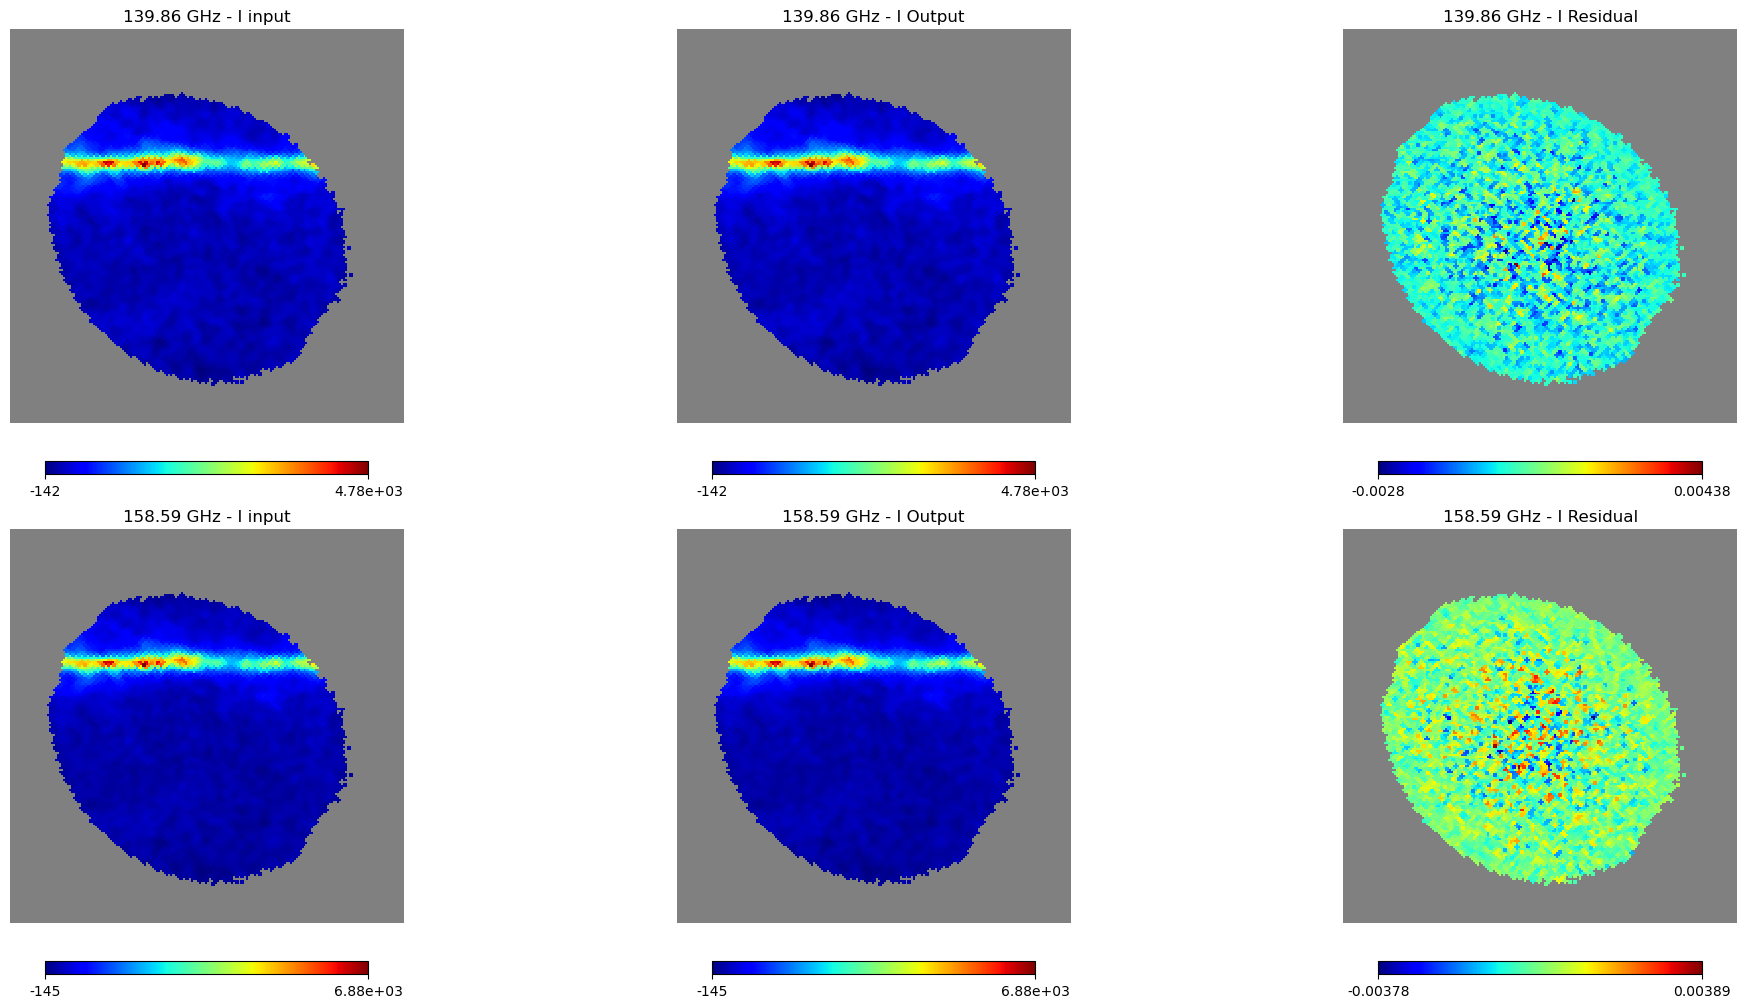

In [8]:
STOKES = ["I", "Q", "U"]

maps_input_jan[:, ~seenpix_jan, :] = hp.UNSEEN
maps_rec_jan[:, ~seenpix_jan, :] = hp.UNSEEN
maps_res_jan[:, ~seenpix_jan, :] = hp.UNSEEN

istk = 0
n = 2
# sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
# sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
# sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input_jan[inu, :, istk]), rot=center_jan,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec_jan[inu, :, istk]), rot=center_jan,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res_jan[inu, :, istk], rot=center_jan,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    #plt.savefig('/home/mattia/Desktop/1sec.png')

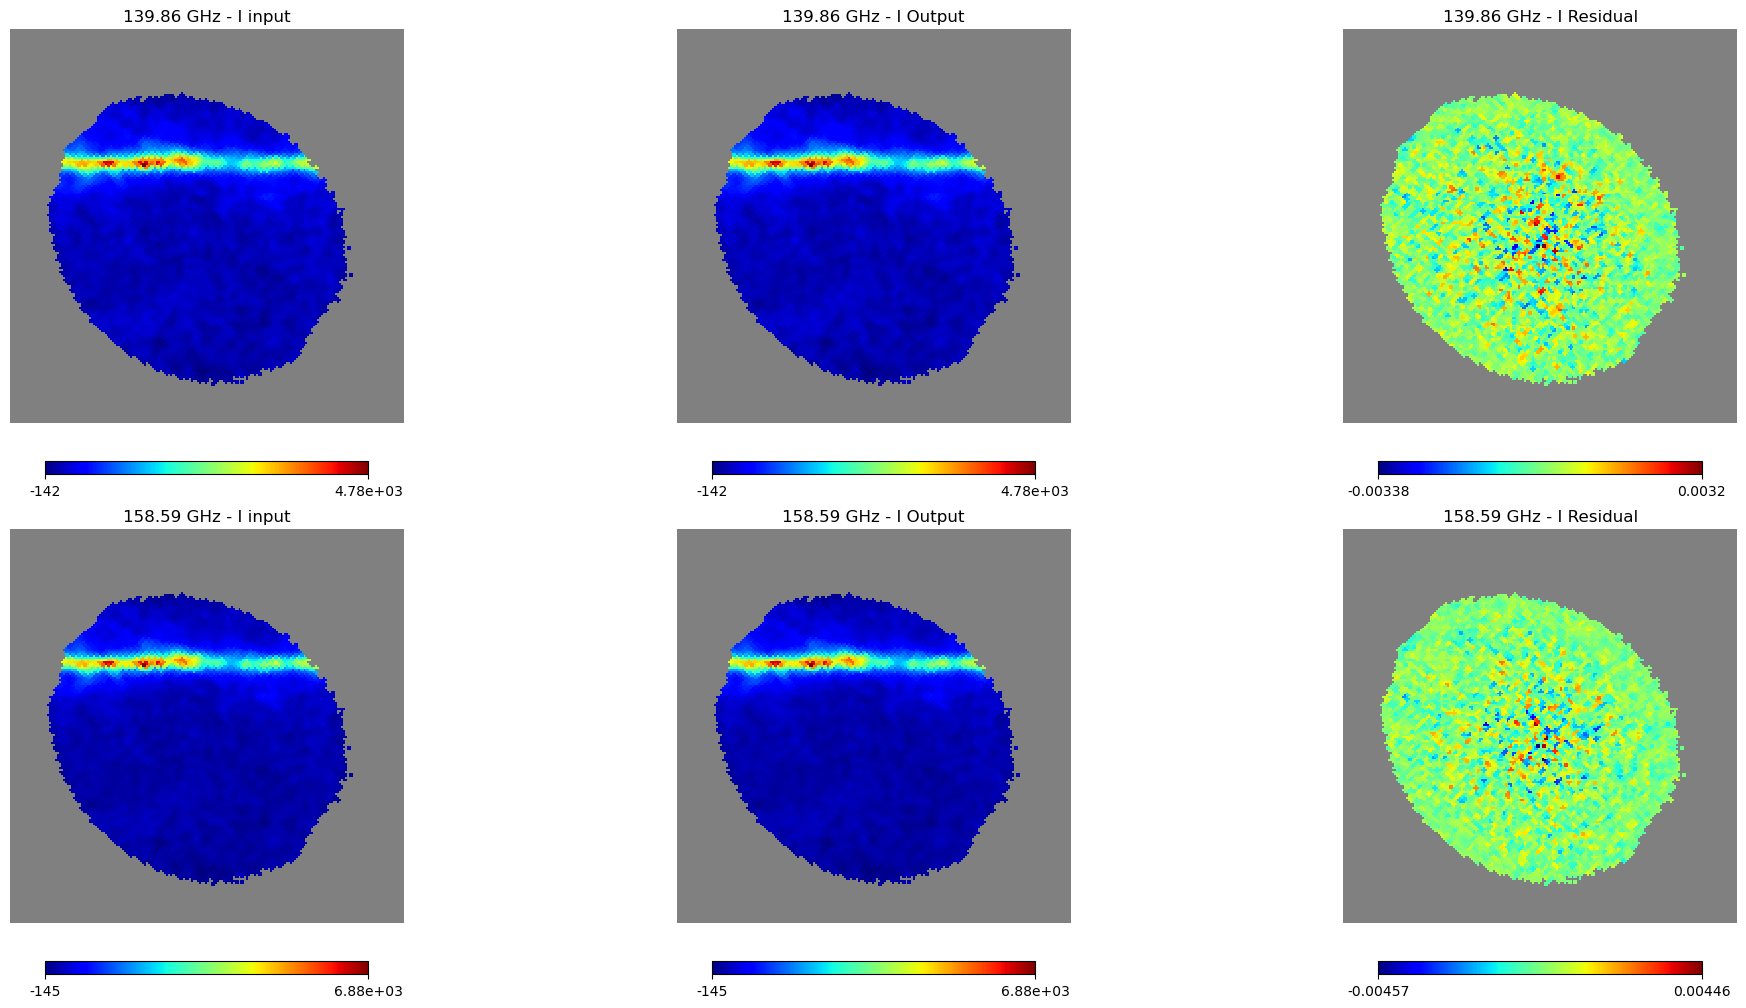

In [9]:
maps_input_feb[:, ~seenpix_feb, :] = hp.UNSEEN
maps_rec_feb[:, ~seenpix_feb, :] = hp.UNSEEN
maps_res_feb[:, ~seenpix_feb, :] = hp.UNSEEN

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input_feb[inu, :, istk]), rot=center_feb,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec_feb[inu, :, istk]), rot=center_feb,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res_feb[inu, :, istk], rot=center_feb,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    #plt.savefig('/home/mattia/Desktop/1sec.png')

In [10]:
maps_input_11 = (maps_input_jan + maps_input_feb) / 2
maps_rec_11 = (maps_rec_jan + maps_rec_feb) / 2
maps_res_11 = (maps_res_jan + maps_res_feb) / 2

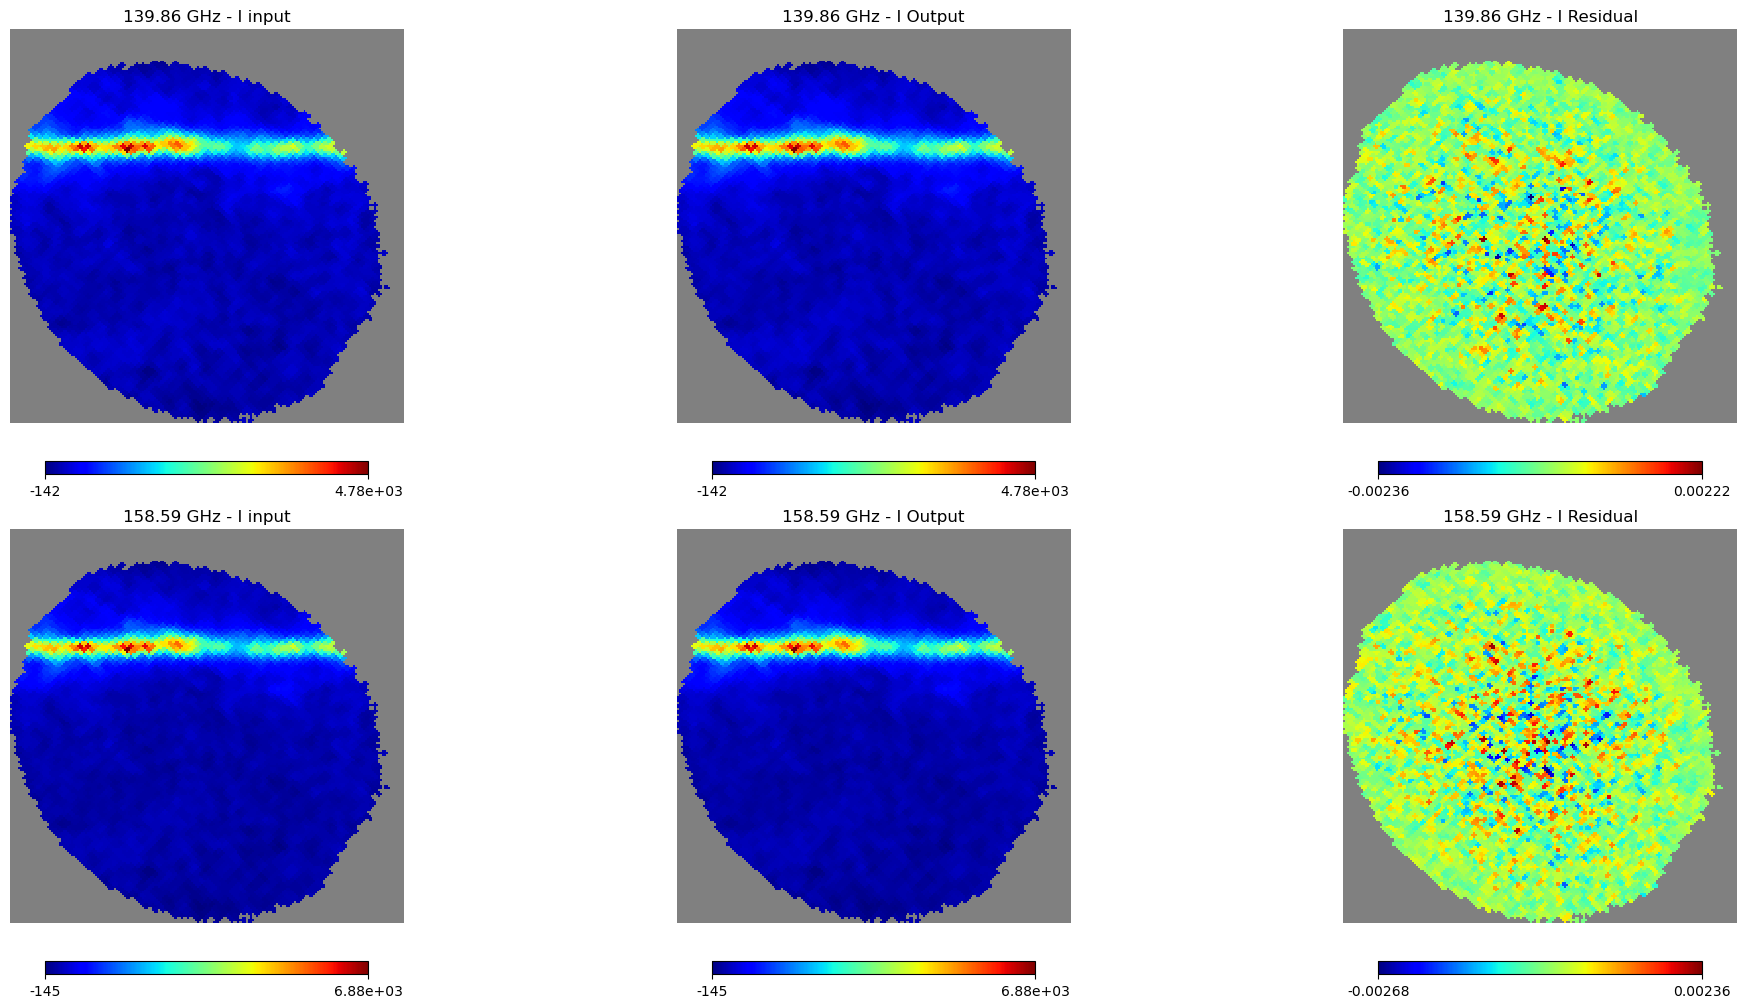

In [14]:
maps_input_11[:, ~seenpix_feb, :] = hp.UNSEEN
maps_rec_11[:, ~seenpix_feb, :] = hp.UNSEEN
maps_res_11[:, ~seenpix_feb, :] = hp.UNSEEN

k = 0
reso = 12

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input_11[inu, :, istk]), rot=center_feb,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec_11[inu, :, istk]), rot=center_feb,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res_11[inu, :, istk], rot=center_feb,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    plt.savefig('/home/mattia/Desktop/figures/janfeb_mean.png')

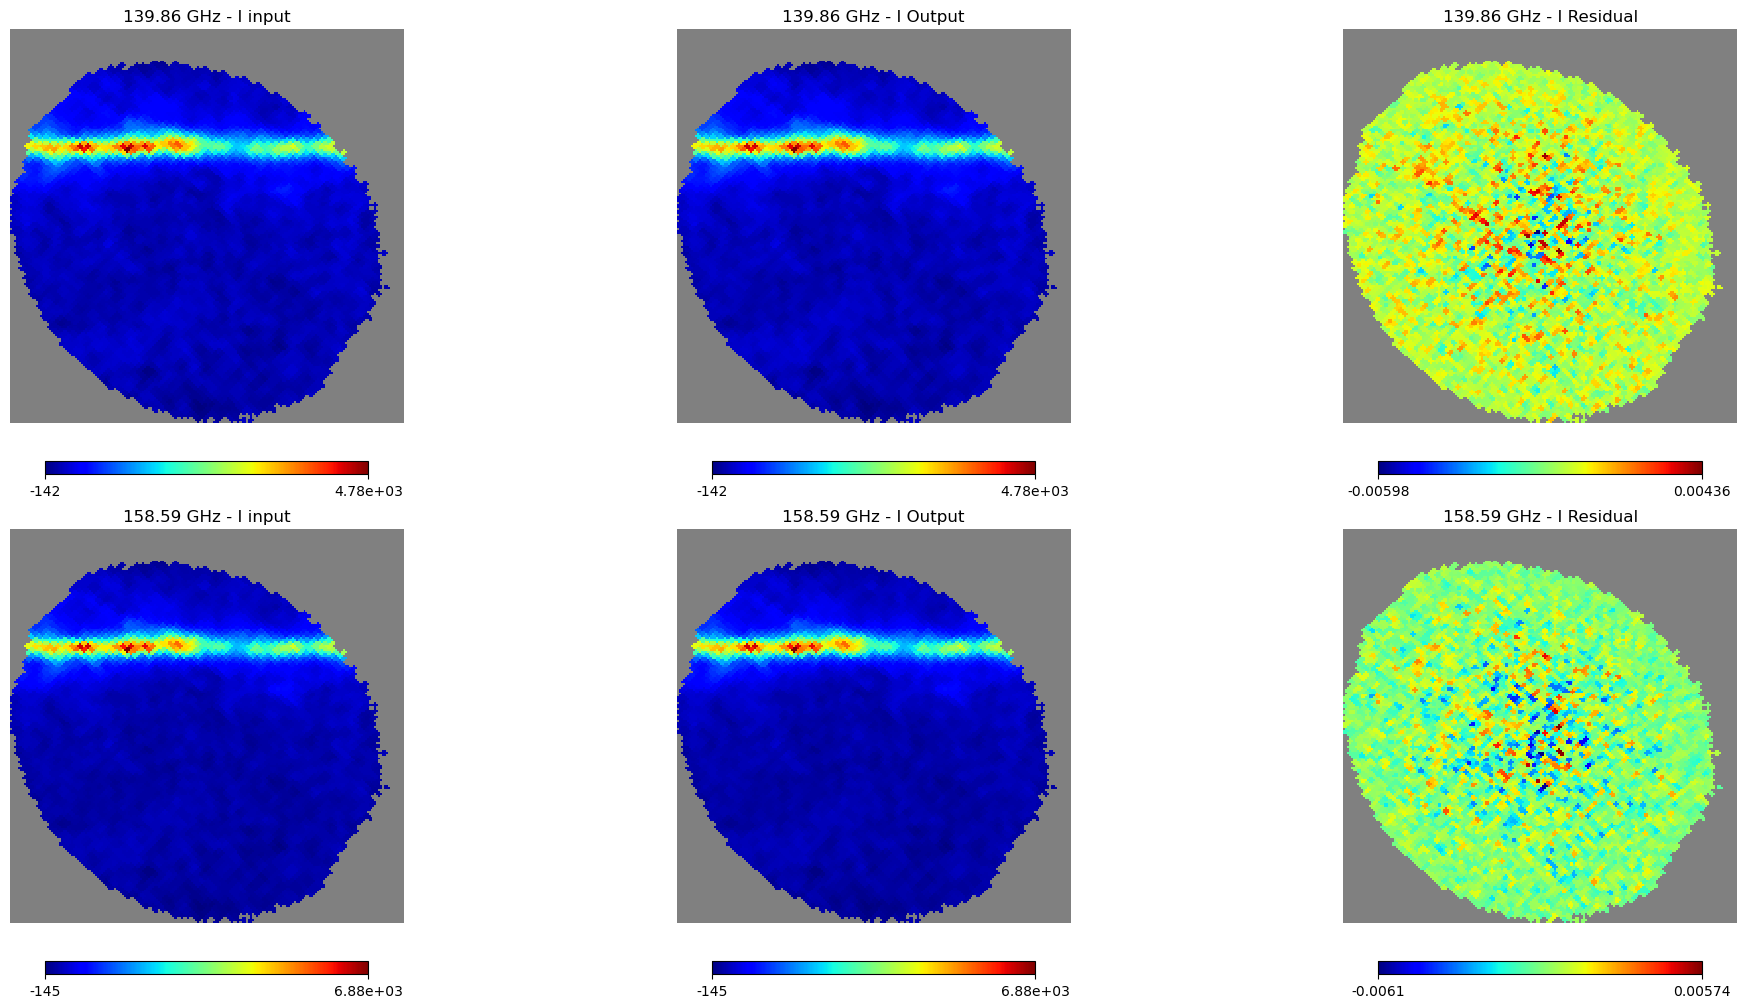

In [ ]:
STOKES = ["I", "Q", "U"]
istk = 0
reso = 12

maps_input_2[:, ~seenpix_2, :] = hp.UNSEEN
maps_rec_2[:, ~seenpix_2, :] = hp.UNSEEN
maps_res_2[:, ~seenpix_2, :] = hp.UNSEEN

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input_2[inu, :, istk]), rot=center_2,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec_2[inu, :, istk]), rot=center_2,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res_2[inu, :, istk], rot=center_2,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3
    #plt.savefig('/home/mattia/Desktop/figures/janfeb.png')

In [21]:
brightest_pix_input = np.argmax(maps_input_2[0, :, 0])   # indice del pixel con valore massimo
brightest_pix = np.argmax(maps_rec_2[0, :, 0])   # indice del pixel con valore massimo
theta, phi = hp.pix2ang(128, brightest_pix)  # coordinate del pixel più luminoso

brightest_val = maps_rec_2[:,brightest_pix,0]
brightest_val_true = maps_input_2[:,brightest_pix,0]

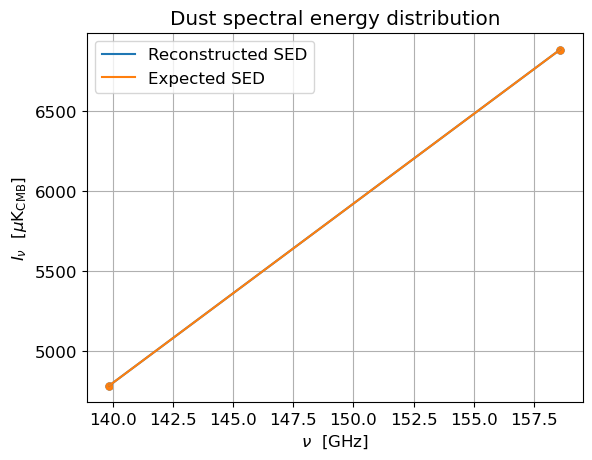

In [23]:
plt.rcParams.update({'font.size':12})


plt.plot(nus[0:2], brightest_val, label='Reconstructed SED')
plt.scatter(nus[0:2], brightest_val, marker='.', s=100)

plt.plot(nus[0:2], brightest_val_true, label='Expected SED')
plt.scatter(nus[0:2], brightest_val_true, marker='.', s=100)


#plt.yscale('log')
plt.xlabel(r'$\nu \ $ [GHz]')
plt.ylabel(r'$I_{\nu} \ \ [\mu \mathrm{K_{CMB}}]$')
plt.title('Dust spectral energy distribution')
plt.grid(which='both', axis='both')
plt.legend()

#plt.savefig('/home/mattia/Desktop/figures/central_right_sed.pdf', bbox_inches='tight')


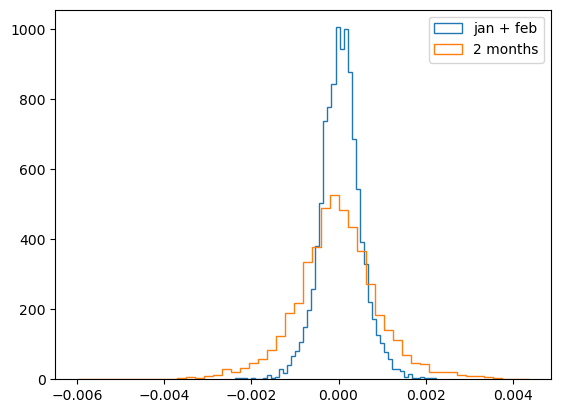

In [16]:
plt.hist(maps_res_11[0,:,0][maps_res_11[0,:,0]>-1], density=True, bins=50, histtype='step', label='jan + feb')
plt.hist(maps_res_2[0,:,0][maps_res_2[0,:,0]>-1], density=True, bins=50, histtype='step', label='2 months')
plt.legend()

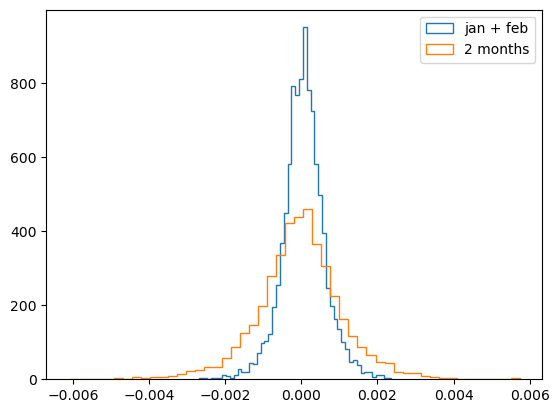

: 

In [ ]:
plt.hist(maps_res_11[1,:,0][maps_res_11[1,:,0]>-1], density=True, bins=50, histtype='step', label='jan + feb')
plt.hist(maps_res_2[1,:,0][maps_res_2[1,:,0]>-1], density=True, bins=50, histtype='step', label='2 months')
plt.legend()